In [1]:
import pandas as pd
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect(
    "../database/sustainability.db"
)

print("Database Connected")

Database Connected


In [3]:
query = """
SELECT
    c.country_name,
    r.year,
    r.renewables_share_energy,
    e.co2

FROM Countries c

JOIN RenewableEnergy r
ON c.country_id = r.country_id

JOIN CO2Emissions e
ON c.country_id = e.country_id
AND r.year = e.year
"""

data = pd.read_sql_query(
    query,
    conn
)

data.head()

,country_name,year,renewables_share_energy,co2
0,China,2000,5.335688,3643.810
1,China,2001,6.251407,3724.114
2,China,2002,5.921867,4098.181
3,China,2003,5.001339,4835.251
4,China,2004,5.289435,5210.961


In [4]:
data.isnull().sum()

country_name               0
year                       0
renewables_share_energy    0
co2                        0
dtype: int64

In [5]:
X = data[['renewables_share_energy']]

Y = data['co2']

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

Training Rows: 134
Testing Rows: 34


In [7]:
model = LinearRegression()

In [8]:
model.fit(
    X_train,
    Y_train
)

print("Model Trained")

Model Trained


In [9]:
predictions = model.predict(
    X_test
)

predictions[:10]

array([1661.27800649, 3037.84794265, 1155.2980472 , 3120.96444483,
        865.71938475, 2600.9637326 , 2405.06198171, 3356.45906231,
       2404.55183086, 2213.70449138])

In [10]:
mae = mean_absolute_error(
    Y_test,
    predictions
)

mse = mean_squared_error(
    Y_test,
    predictions
)

r2 = r2_score(
    Y_test,
    predictions
)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

MAE: 2762.734249597355
MSE: 12736306.187528696
R²: 0.006221614997810709


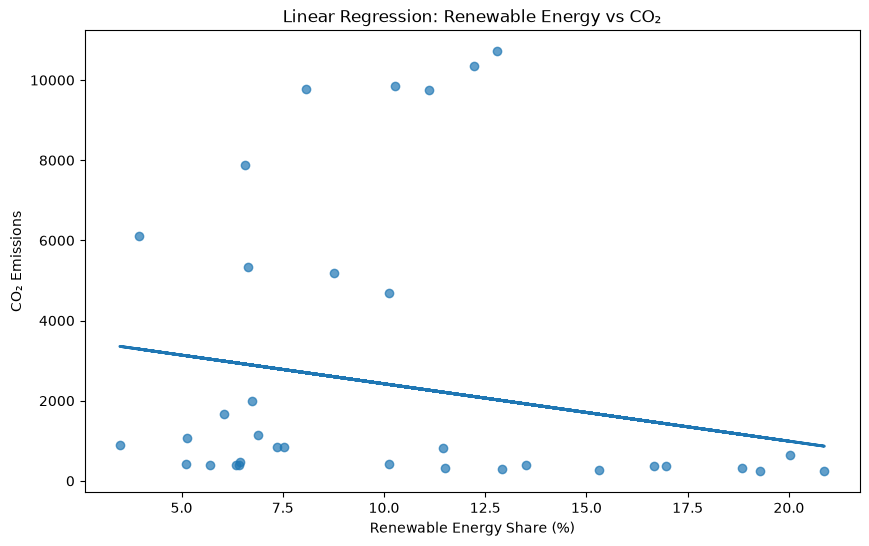

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_test,
    Y_test,
    alpha=0.7
)

plt.plot(
    X_test,
    predictions,
    linewidth=2
)

plt.xlabel(
    "Renewable Energy Share (%)"
)

plt.ylabel(
    "CO₂ Emissions"
)

plt.title(
    "Linear Regression: Renewable Energy vs CO₂"
)

plt.savefig(
    "../visuals/regression_model.png",
    dpi=300,
    bbox_inches="tight"
)